In [16]:
import pandas as pd
import matplotlib as mpl
import numpy as np
import seaborn as sb
import missingno as msno
from IPython.display import Image
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
df_inventory = pd.read_csv('../data/inventory.csv')
df_orders = pd.read_csv('../data/orders.csv')
df_order_items = pd.read_csv('../data/order_items.csv')
df_products = pd.read_csv('../data/products.csv')

/tmp/ipykernel_7110/1619349790.py:3: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv('../data/order_items.csv')


In [5]:
print("--- Inventory Null Counts ---")
print(df_inventory.isnull().sum())

print("\n--- Orders Null Counts ---")
print(df_orders.isnull().sum())

print("\n--- Order Items Null Counts ---")
print(df_order_items.isnull().sum())

print("\n--- Products Null Counts ---")
print(df_products.isnull().sum())

--- Inventory Null Counts ---
snapshot_date        0
product_id           0
stock_on_hand        0
units_received       0
units_sold           0
stockout_days        0
days_of_supply       0
fill_rate            0
stockout_flag        0
overstock_flag       0
reorder_flag         0
sell_through_rate    0
product_name         0
category             0
segment              0
year                 0
month                0
dtype: int64

--- Orders Null Counts ---
order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
dtype: int64

--- Order Items Null Counts ---
order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64

--- Products Null Counts ---
product_id      0
product_name    0
category        0
segment         0
size            0
color           0

In [6]:
df_order_items['promo_id'] = df_order_items['promo_id'].fillna('NO_PROMO')
df_order_items['promo_id_2'] = df_order_items['promo_id_2'].fillna('NO_PROMO')

df_order_items

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NO_PROMO,NO_PROMO
1,2,609,7,10166.25,0.0,NO_PROMO,NO_PROMO
2,3,396,3,11220.33,0.0,NO_PROMO,NO_PROMO
3,4,635,5,10639.25,0.0,NO_PROMO,NO_PROMO
4,6,1935,1,1597.84,0.0,NO_PROMO,NO_PROMO
...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NO_PROMO,NO_PROMO
714665,834377,1995,7,5250.79,0.0,NO_PROMO,NO_PROMO
714666,834387,2331,8,7389.06,0.0,NO_PROMO,NO_PROMO
714667,834392,1115,5,4767.33,0.0,NO_PROMO,NO_PROMO


ERD diagram:


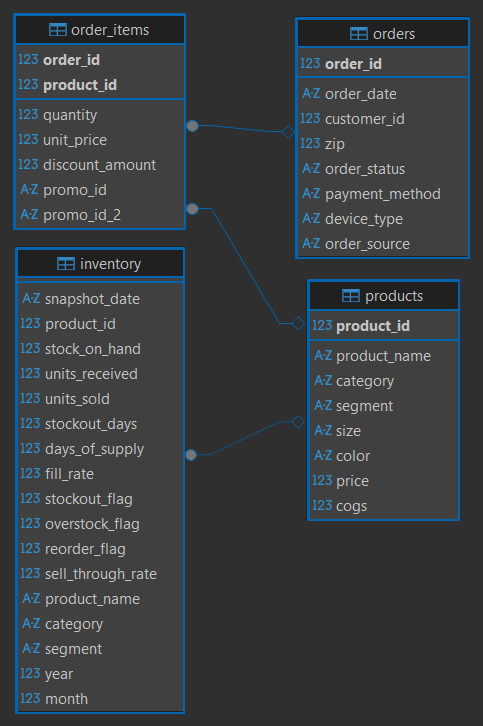

In [8]:
print('ERD diagram:')

Image("/mnt/c/Users/Admin/Downloads/DATATHON.PNG")

In [29]:
df_merged_table1 = df_order_items.merge(df_orders, on='order_id', how='left')

df_merged_table2 = df_merged_table1.merge(df_products, on='product_id', how='left')

df_merged_table2

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip,...,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs
0,1,2400,7,1138.22,0.0,NO_PROMO,NO_PROMO,2012-07-04,58578,1109,...,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008
1,2,609,7,10166.25,0.0,NO_PROMO,NO_PROMO,2012-07-04,58621,1330,...,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231
2,3,396,3,11220.33,0.0,NO_PROMO,NO_PROMO,2012-07-04,58811,1473,...,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256
3,4,635,5,10639.25,0.0,NO_PROMO,NO_PROMO,2012-07-04,59453,2360,...,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478
4,6,1935,1,1597.84,0.0,NO_PROMO,NO_PROMO,2012-07-06,57821,2886,...,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NO_PROMO,NO_PROMO,2022-12-31,19490,33907,...,credit_card,mobile,email_campaign,SaigonFlex UC-55,Streetwear,Everyday,L,red,4598.817231,3100.062695
714665,834377,1995,7,5250.79,0.0,NO_PROMO,NO_PROMO,2022-12-31,73046,37091,...,credit_card,mobile,referral,UrbanVN UM-02,Streetwear,Balanced,XL,purple,5159.312851,3025.421056
714666,834387,2331,8,7389.06,0.0,NO_PROMO,NO_PROMO,2022-12-31,107723,80516,...,credit_card,mobile,email_campaign,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431
714667,834392,1115,5,4767.33,0.0,NO_PROMO,NO_PROMO,2022-12-31,139431,93510,...,paypal,desktop,direct,MekongFit RS-03,Outdoor,Premium,XL,purple,4828.925117,4587.478861


In [30]:
df_merged_table2['unit_price'] = pd.to_numeric(df_merged_table2['unit_price'], errors='coerce')
df_merged_table2['quantity'] = pd.to_numeric(df_merged_table2['quantity'], errors='coerce')
df_merged_table2['cogs'] = pd.to_numeric(df_merged_table2['cogs'], errors='coerce')

df_merged_table2['total_revenue'] = df_merged_table2['unit_price'] * df_merged_table2['quantity']
df_merged_table2['total_cost'] = df_merged_table2['cogs'] * df_merged_table2['quantity']
df_merged_table2['total_profit'] = df_merged_table2['total_revenue'] - df_merged_table2['total_cost']
df_merged_table2['profit_margin'] = (df_merged_table2['total_profit'] / df_merged_table2['total_revenue']) * 100

df_merged_table2

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip,...,category,segment,size,color,price,cogs,total_revenue,total_cost,total_profit,profit_margin
0,1,2400,7,1138.22,0.0,NO_PROMO,NO_PROMO,2012-07-04,58578,1109,...,GenZ,Trendy,S,red,1109.261061,1053.798008,7967.54,7376.586059,590.953941,7.417019
1,2,609,7,10166.25,0.0,NO_PROMO,NO_PROMO,2012-07-04,58621,1330,...,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,71163.75,62913.929616,8249.820384,11.592729
2,3,396,3,11220.33,0.0,NO_PROMO,NO_PROMO,2012-07-04,58811,1473,...,Streetwear,Balanced,S,green,11028.428695,10091.012256,33660.99,30273.036767,3387.953233,10.064925
3,4,635,5,10639.25,0.0,NO_PROMO,NO_PROMO,2012-07-04,59453,2360,...,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,53196.25,46027.152390,7169.097610,13.476697
4,6,1935,1,1597.84,0.0,NO_PROMO,NO_PROMO,2012-07-06,57821,2886,...,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,1597.84,1048.696357,549.143643,34.367874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NO_PROMO,NO_PROMO,2022-12-31,19490,33907,...,Streetwear,Everyday,L,red,4598.817231,3100.062695,35791.36,24800.501564,10990.858436,30.708133
714665,834377,1995,7,5250.79,0.0,NO_PROMO,NO_PROMO,2022-12-31,73046,37091,...,Streetwear,Balanced,XL,purple,5159.312851,3025.421056,36755.53,21177.947390,15577.582610,42.381602
714666,834387,2331,8,7389.06,0.0,NO_PROMO,NO_PROMO,2022-12-31,107723,80516,...,Streetwear,Performance,XL,black,7365.661770,6671.816431,59112.48,53374.531451,5737.948549,9.706831
714667,834392,1115,5,4767.33,0.0,NO_PROMO,NO_PROMO,2022-12-31,139431,93510,...,Outdoor,Premium,XL,purple,4828.925117,4587.478861,23836.65,22937.394304,899.255696,3.772576


In [31]:
categorical_cols = [
    'payment_method', 'order_status', 'order_source', 'device_type', 
    'category', 'segment', 'size', 'color', 'zip'
]

for col in categorical_cols:
    if col in df_merged_table2.columns:
        df_count = df_merged_table2[col].value_counts().sort_values(ascending=False).reset_index()
        df_count.columns = [col.capitalize(), 'Count']
        
        # Saves the variable (e.g., payment_method_count)
        globals()[f"{col}_count"] = df_count
        
        print(f"\n--- {col}_count ---")
        display(df_count)


--- payment_method_count ---


,Payment_method,Count
0,credit_card,393421
1,paypal,107230
2,cod,106965
3,apple_pay,71510
4,bank_transfer,35543



--- order_status_count ---


,Order_status,Count
0,delivered,570887
1,cancelled,65673
2,returned,40034
3,shipped,15094
4,paid,14987
5,created,7994



--- order_source_count ---


...

,Size,Count
0,XL,193025
1,M,176428
2,L,173174
3,S,172042



--- color_count ---


,Color,Count
0,purple,94848
1,green,82112
2,white,79680
3,orange,74392
4,yellow,73666
5,silver,70640
6,black,67118
7,blue,63181
8,red,58140
9,pink,50892



--- zip_count ---


,Zip,Count
0,93065,704
1,92592,640
2,92882,469
3,93536,453
4,90250,443
...,...,...
29927,69025,1
29928,41759,1
29929,73650,1
29930,56433,1
